In [ ]:
||import pandas as pd

dados = {
    "ano": [
        1989,
        1996,
        2005,
        2011,
        2020,
        2023
    ],

    "populacao_milhoes": [
        147.0,
        161.0,
        184.0,
        196.0,
        213.0,
        203.0
    ],

    "percentual_fumantes": [
        34.8,
        29.0,
        22.4,
        18.1,
        12.6,
        13.2
    ],

    "ipi_aproximado": [
    41.25,
    45.0,
    60.0,
    70.0,
    78.0,
    78.0 # Período de estagnação
],

    "evento": [
        "Campanhas nacionais antitabagismo",
        "Restrição da propaganda de cigarros",
        "Ratificação da Convenção-Quadro (CQCT)",
        "Lei antifumo nacional",
        "Consolidação de ambientes livres de fumaça",
        "Popularização dos cigarros eletrônicos"
    ],

    "hipotese": [
        "Início de campanhas públicas de conscientização",
        "Redução da exposição da população à publicidade do tabaco",
        "Fortalecimento das políticas públicas de controle do tabagismo",
        "Restrição do uso em ambientes fechados",
        "Queda consolidada no número de fumantes",
        "Possível influência do aumento do uso de cigarros eletrônicos entre jovens"
    ]
}

# =====================================================
# CRIA DATAFRAME
# =====================================================

df = pd.DataFrame(dados)

# =====================================================
# CALCULA ESTIMATIVA DE FUMANTES
# =====================================================

df["fumantes_estimados_milhoes"] = (
    df["populacao_milhoes"]
    * (df["percentual_fumantes"] / 100)
)

# =====================================================
# CALCULA VARIAÇÃO PERCENTUAL
# =====================================================

df["variacao_percentual"] = (
    df["percentual_fumantes"]
    .pct_change()
    * 100
)

# =====================================================
# FORMATAÇÕES
# =====================================================

df["percentual_formatado"] = (
    df["percentual_fumantes"]
    .astype(str)
    + "%"
)

df["fumantes_estimados_formatado"] = (
    df["fumantes_estimados_milhoes"]
    .round(1)
    .astype(str)
    + " milhões"
)

df["variacao_formatada"] = (
    df["variacao_percentual"]
    .round(2)
    .astype(str)
    + "%"
)

# =====================================================
# RESULTADO
# =====================================================

print("\n===== HISTÓRICO DO TABAGISMO NO BRASIL =====")
print(df)


===== HISTÓRICO DO TABAGISMO NO BRASIL =====
    ano  populacao_milhoes  percentual_fumantes  ipi_aproximado  \
0  1989              147.0                 34.8           41.25   
1  1996              161.0                 29.0           45.00   
2  2005              184.0                 22.4           60.00   
3  2011              196.0                 18.1           70.00   
4  2020              213.0                 12.6           78.00   
5  2023              203.0                 13.2           78.00   

                                       evento  \
0           Campanhas nacionais antitabagismo   
1         Restrição da propaganda de cigarros   
2      Ratificação da Convenção-Quadro (CQCT)   
3                       Lei antifumo nacional   
4  Consolidação de ambientes livres de fumaça   
5      Popularização dos cigarros eletrônicos   

                                            hipotese  \
0    Início de campanhas públicas de conscientização   
1  Redução da exposição da p

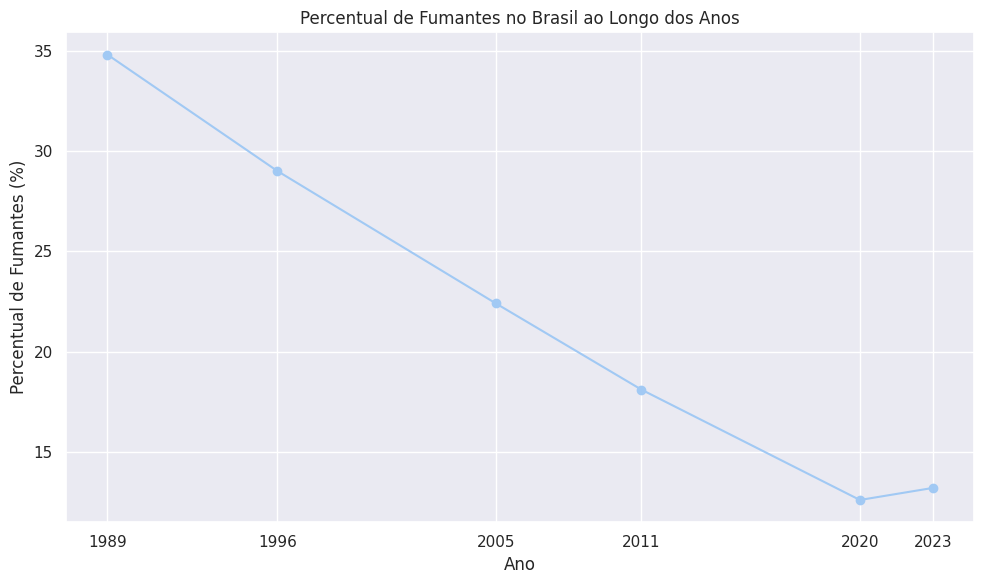

In [ ]:
import matplotlib.pyplot as plt
# Gerando gráficos relevantes pra analise
plt.figure(figsize=(10, 6))
plt.plot(df['ano'], df['percentual_fumantes'], marker='o', linestyle='-')
plt.title('Percentual de Fumantes no Brasil ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Percentual de Fumantes (%)')
plt.grid(True)
plt.xticks(df['ano'])
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Percentual de Fumantes (%)')

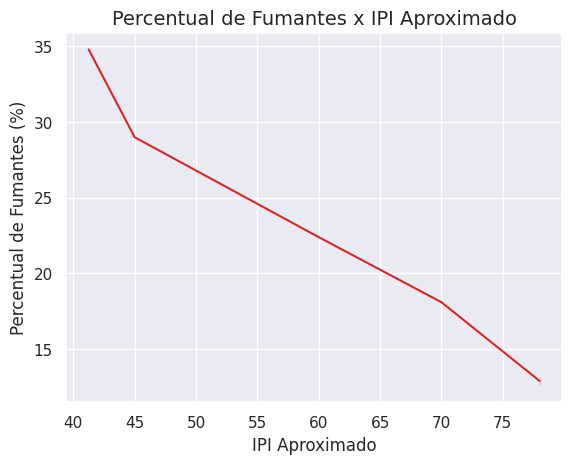

In [ ]:
IPI_fumantes = sns.lineplot(data = df, x='ipi_aproximado', y='percentual_fumantes', color='#d62728')
IPI_fumantes.set_title('Percentual de Fumantes x IPI Aproximado', fontsize=14)
IPI_fumantes.set_xlabel('IPI Aproximado')
IPI_fumantes.set_ylabel('Percentual de Fumantes (%)')

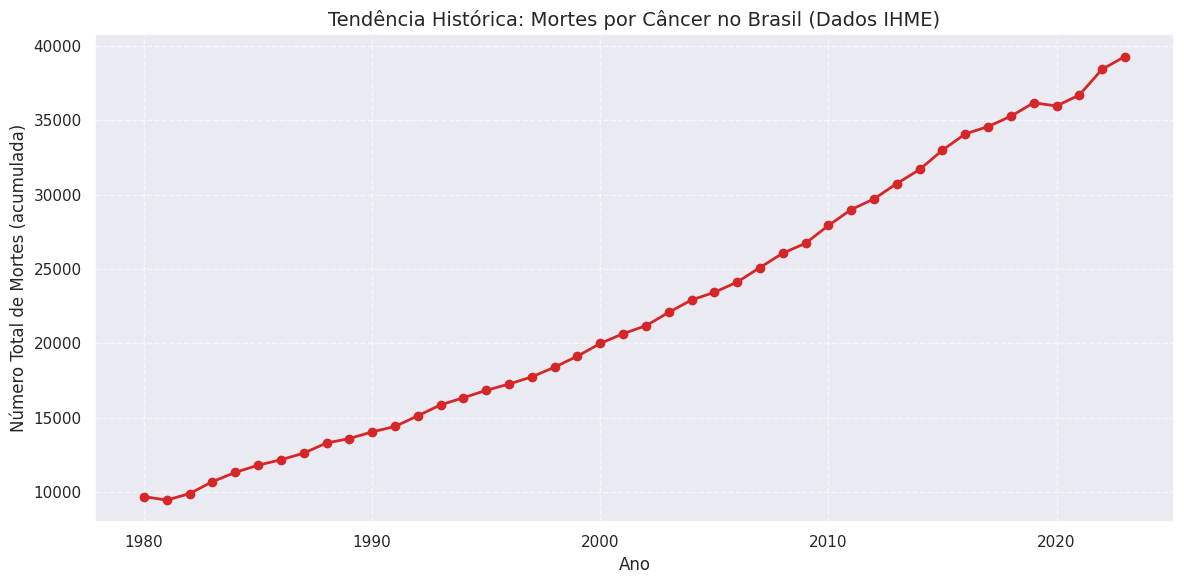

,year,val
39,2019,36188.497770
40,2020,35974.414270
41,2021,36711.854813
42,2022,38446.378434
43,2023,39304.513447


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregamento e Processamento de Dados (Novo Arquivo IHME)
# Atualizado conforme solicitação para evitar excesso de dados (DALYs)
file_path = '/content/IHME-GBD_2023_DATA-cabfebd7-1.csv'
df_ihme = pd.read_csv(file_path)

# Filtragem: apenas Brasil, métrica absoluta (Number) para evitar taxas entre 0 e 1
df_tendencia = df_ihme[
    (df_ihme['location'] == 'Brazil') &
    (df_ihme['metric'] == 'Number')
].groupby('year')['val'].sum().reset_index()

# 2. Visualização do Número Total de Mortes
plt.figure(figsize=(12, 6))
plt.plot(df_tendencia['year'], df_tendencia['val'], marker='o', linestyle='-', color='#d62728', linewidth=2)

plt.title('Tendência Histórica: Mortes por Câncer no Brasil (Dados IHME)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número Total de Mortes (acumulada)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Formatação para evitar notação científica no eixo Y
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# Exibição dos dados processados
display(df_tendencia.tail())

Seleção de mais doenças relacionadas ao tabagismo com base nas informações do govbr

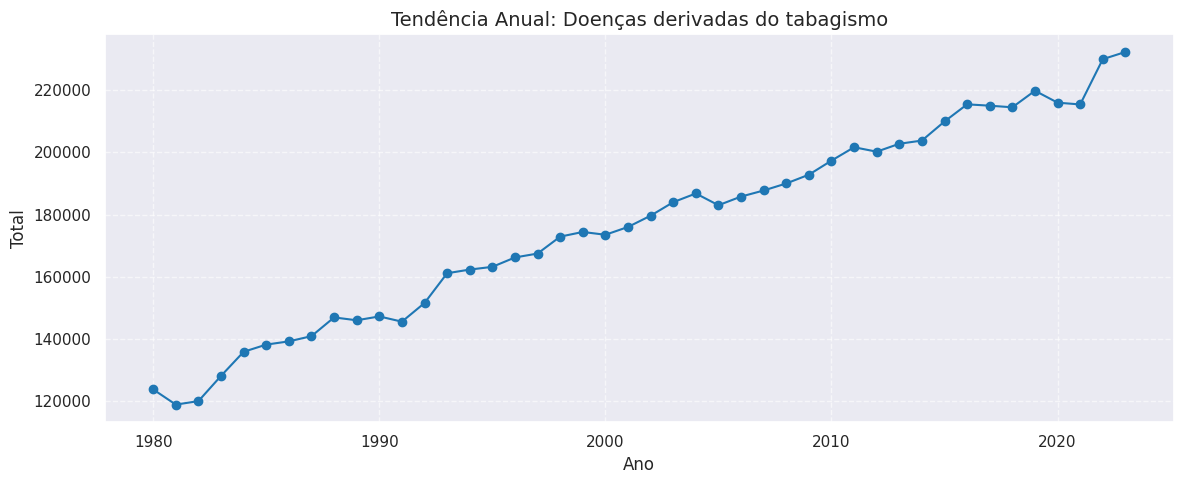

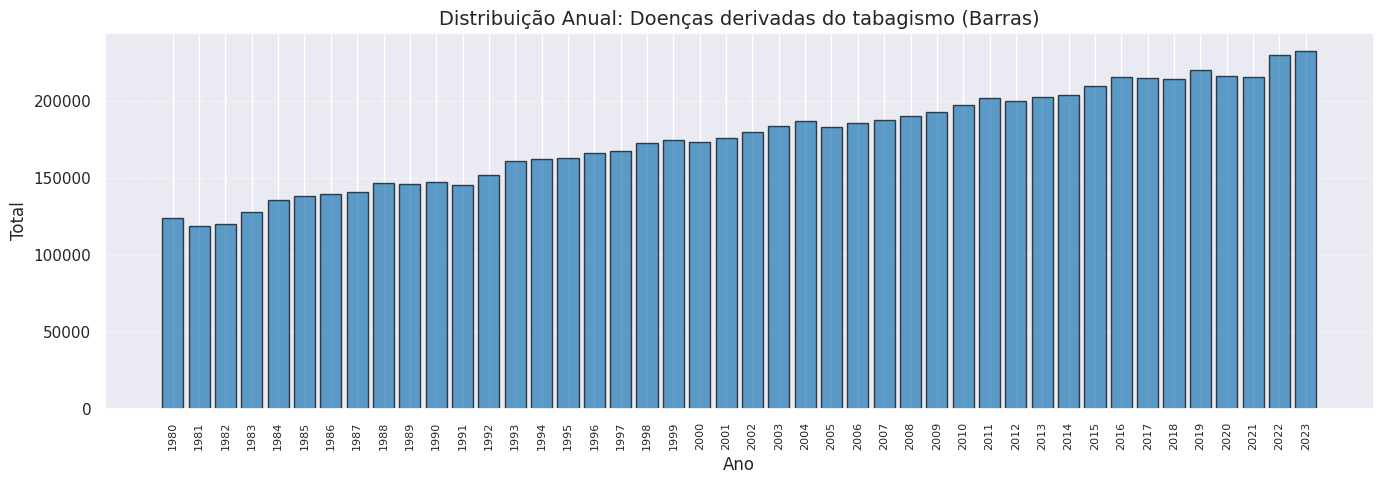

,year,val,upper,lower
39,2019,219825.486289,236525.671426,198157.677358
40,2020,215998.727261,230204.877667,196008.717803
41,2021,215425.200772,229038.962631,196332.410463
42,2022,229975.763210,245542.387765,208653.449007
43,2023,232295.749415,249096.257295,208124.712534


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregamento e Processamento do Novo Arquivo
file_path_novo = '/content/multiplas_causas.csv'
df_novas_causas = pd.read_csv(file_path_novo)

# Agrupando por ano (ajustando para somar a coluna de valor, assumindo que se chama 'val' ou similar conforme o padrão anterior)
# Caso a coluna tenha outro nome, o pandas tentará identificar colunas numéricas
df_agrupado_novo = df_novas_causas.groupby('year').sum(numeric_only=True).reset_index()

# 2. Gráfico de Linha
plt.figure(figsize=(12, 5))
plt.plot(df_agrupado_novo['year'], df_agrupado_novo['val'], marker='o', color='#1f77b4', label='Total por Ano')
plt.title('Tendência Anual: Doenças derivadas do tabagismo', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Total')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Gráfico de Barras
plt.figure(figsize=(14, 5))
plt.bar(df_agrupado_novo['year'], df_agrupado_novo['val'], color='#1f77b4', alpha=0.7, edgecolor='black')
plt.title('Distribuição Anual: Doenças derivadas do tabagismo (Barras)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Total')
plt.xticks(df_agrupado_novo['year'], rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(df_agrupado_novo.tail())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
historico = sns.lineplot(data = df, x='ano', y='percentual_fumantes', color='#d62728')
historico.set_title('Percentual de Fumantes no Brasil ao Longo dos Anos', fontsize=14)
historico.set_xlabel('Ano')
historico.set_ylabel('Percentual de Fumantes (%)')
historico

NameError: name 'sns' is not defined

<Axes: title={'center': 'Distribuição Anual: Mortes por doenças derivadas do tabagismo'}, xlabel='Ano', ylabel='Total'>

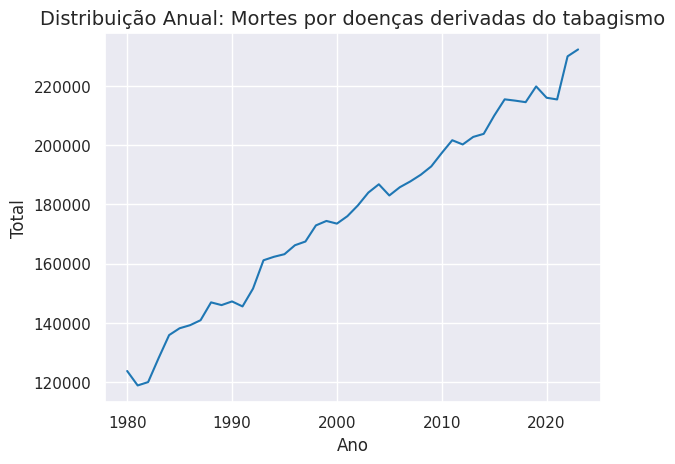

In [ ]:
import seaborn as sns
sns.set_theme(style='darkgrid',palette='pastel')
hist = sns.lineplot(data= df_agrupado_novo, x='year', y='val', color='#1f77b4')
hist.set_title('Distribuição Anual: Mortes por doenças derivadas do tabagismo', fontsize=14)
hist.set_xlabel('Ano')
hist.set_ylabel('Total')
hist

Quando esses dois gráficos são colocados lado a lado, fica notório que mesmo com a grande diminuição da proporção de fumantes no Brasil as mortes derivadas de doenças relacionadas ao tabagismo continuaram aumentando. Porém, por serem dados históricos e de um período em que o registro de dados não era tão estrito, por causa disso pode acabar tendo viés ou uma distorção dos dados. Além disso, quando analisamos a proporção é possível que a diminuição, por conta do aumento populacional no país (142.6M em 1989 e 203.1M em 2023), tenha sido inflada.

Text(0, 0.5, 'Total de Fumantes Estimados (Milhões)')

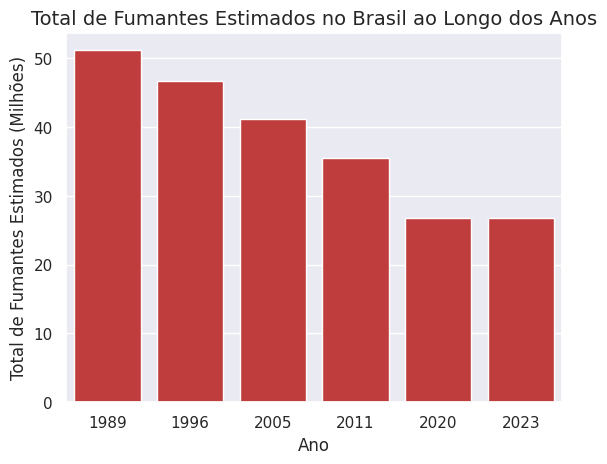

In [ ]:
total_fumantes = sns.barplot(data = df, x='ano', y='fumantes_estimados_milhoes', color='#d62728')
total_fumantes.set_title('Total de Fumantes Estimados no Brasil ao Longo dos Anos', fontsize=14)
total_fumantes.set_xlabel('Ano')
total_fumantes.set_ylabel('Total de Fumantes Estimados (Milhões)')